# Spam Dataset Exploration

Week 1 focuses on loading the raw Kaggle CSV, checking its basic structure, and preparing it for text preprocessing.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name == 'notebooks':
    WEEK1_ROOT = NOTEBOOK_DIR.parent
elif (NOTEBOOK_DIR / 'week-1').exists():
    WEEK1_ROOT = NOTEBOOK_DIR / 'week-1'
else:
    WEEK1_ROOT = NOTEBOOK_DIR

sys.path.insert(0, str(WEEK1_ROOT))
from src.preprocess import (
    load_dataset,
    preprocess_dataset,
    remove_nulls_and_duplicates,
    resolve_columns,
)

DATA_PATH = WEEK1_ROOT / 'data' / 'spam_raw.csv'
if DATA_PATH.exists():
    df = load_dataset(DATA_PATH)
    print(f'Loaded dataset: {DATA_PATH}')
else:
    df = pd.DataFrame([
        ('ham', 'Project meeting is scheduled tomorrow'),
        ('ham', 'Please send the report this afternoon'),
        ('ham', 'Can you share the class notes'),
        ('ham', 'Thanks for sending the document'),
        ('ham', 'See you at the office tomorrow'),
        ('spam', 'Win a free cash prize claim now'),
        ('spam', 'Urgent reward selected click link'),
        ('spam', 'Congratulations receive bonus money today'),
        ('spam', 'Exclusive offer reply to win'),
        ('spam', 'You have won a shopping voucher'),
    ], columns=['label', 'message'])
    print('WARNING: week-1/data/spam_raw.csv is missing; using embedded demo data.')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 4)

Loaded dataset: D:\Internship-Weekly-Logs\week-1\data\spam_raw.csv


In [2]:
print('Shape:', df.shape)
print('Columns:', list(df.columns))
df.info()

Shape: (5572, 5)
Columns: ['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']
<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [3]:
print('Raw dataset preview:')
display(df.head())

Raw dataset preview:


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
print('Null counts:')
display(df.isnull().sum())

print('Duplicate rows:', df.duplicated().sum())

Null counts:


v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

Duplicate rows: 403


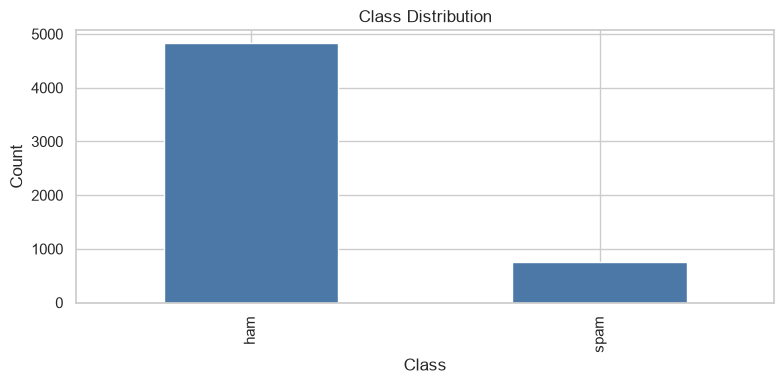

In [5]:
label_col, text_col = resolve_columns(df)
class_counts = df[label_col].astype(str).str.strip().str.lower().value_counts()

ax = class_counts.plot(kind='bar', color='#4C78A8')
ax.set_title('Class Distribution')
ax.set_xlabel('Class')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

In [6]:
sample_rows = df[[label_col, text_col]].head(5)
display(sample_rows)

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
cleaned_preview = remove_nulls_and_duplicates(df, label_col=label_col, text_col=text_col)
print('After removing nulls and duplicates:', cleaned_preview.shape)
display(cleaned_preview.head())

After removing nulls and duplicates: (5169, 5)


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [8]:
processed_df = preprocess_dataset(df, label_col=label_col, text_col=text_col)
print('Full preprocessed dataset shape:', processed_df.shape)
print('\nBinary label distribution (0=ham, 1=spam):')
print(processed_df['label_binary'].value_counts())
print('\nSample preprocessed messages:')
display(processed_df[['label_binary', 'clean_text']].head())

Full preprocessed dataset shape: (5169, 7)

Binary label distribution (0=ham, 1=spam):
label_binary
0    4516
1     653
Name: count, dtype: int64

Sample preprocessed messages:


,label_binary,clean_text
0,0,go jurong point crazy available bugis n great ...
1,0,ok lar joking wif u oni
2,1,free entry wkly comp win fa cup final tkts st ...
3,0,u dun say early hor u c already say
4,0,nah think goes usf lives around though


## Week 2

Feature extraction and model training will be added in the next phase.